# DermaScan — classificação de lesões de pele

Pipeline de treinamento e inferência para classificação multiclasse de imagens dermatoscópicas do conjunto **HAM10000**.

### Objetivo
Treinar uma EfficientNet com separação por `lesion_id`, avaliar o desempenho por imagem e por lesão, calibrar as probabilidades e exportar um checkpoint autocontido para integração com uma aplicação web.

### Fluxo do notebook
1. Preparação e validação do dataset
2. Criação de splits sem vazamento entre lesões
3. Transfer learning e fine-tuning
4. Avaliação, calibração e análise de alertas
5. Exportação dos artefatos e teste real da inferência


## 1. Dependências e imports

In [ ]:
#%pip install -q timm kagglehub
%pip install -q --only-binary=:all: timm==1.0.28 kagglehub==1.0.2


In [ ]:
import base64
import gc
import hashlib
import io
import json
import os
import random
import shutil
import sys
from dataclasses import asdict, dataclass, field
from datetime import datetime, timezone
from pathlib import Path

import ipywidgets as widgets
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import timm
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import clear_output, display
from PIL import Image, ImageOps, UnidentifiedImageError
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    multilabel_confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print(
    f"PyTorch {torch.__version__} | "
    f"dispositivo: {DEVICE}"
)

PyTorch 2.11.0+cu128 | dispositivo: cuda


## 2. Parâmetros do experimento

As configurações abaixo controlam arquitetura, resolução, treinamento e avaliação. Os artefatos são gravados em `artifacts/dermascan` por padrão.

In [ ]:
@dataclass(frozen=True)
class TrainingConfig:
    seed: int = 42
    architecture: str = "efficientnet_b4"
    image_size: int = 380
    batch_size: int = 8
    num_workers: int = min(4, os.cpu_count() or 1)
    epochs_head: int = 4
    epochs_finetune: int = 22
    learning_rate_head: float = 8e-4
    learning_rate_finetune: float = 8e-5
    weight_decay: float = 2e-4
    patience: int = 7
    label_smoothing: float = 0.04
    gradient_clip: float = 1.0
    balance_strategy: str = "effective_weights"
    effective_beta: float = 0.999
    max_class_weight: float = 4.0
    unfreeze_blocks: int = 4
    drop_rate: float = 0.30
    drop_path_rate: float = 0.20
    use_ema: bool = True
    ema_decay: float = 0.999
    final_tta: bool = True


@dataclass(frozen=True)
class EvaluationConfig:
    high_risk_codes: tuple[str, ...] = ("akiec", "bcc", "mel")
    target_recall: dict[str, float] = field(default_factory=lambda: {
        "akiec": 0.82,
        "bcc": 0.88,
        "mel": 0.88,
    })
    bootstrap_iterations: int = 500


TRAINING = TrainingConfig()
EVALUATION = EvaluationConfig()

CLASS_CODES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_NAMES_PT = {
    "akiec": "Ceratose actínica",
    "bcc": "Carcinoma basocelular",
    "bkl": "Ceratose benigna",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Nevo melanocítico",
    "vasc": "Lesão vascular",
}
CODE_TO_IDX = {code: idx for idx, code in enumerate(CLASS_CODES)}
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}
NUM_CLASSES = len(CLASS_CODES)
ALL_LABELS = np.arange(NUM_CLASSES)
MELANOMA_IDX = CODE_TO_IDX["mel"]
HIGH_RISK_IDXS = [CODE_TO_IDX[code] for code in EVALUATION.high_risk_codes]


def resolve_artifact_root() -> Path:
    configured = os.getenv("DERMASCAN_ARTIFACT_DIR")
    return Path(configured).expanduser() if configured else Path("artifacts") / "dermascan"


ARTIFACT_ROOT = resolve_artifact_root()
RUN_NAME = f"{TRAINING.architecture}_{datetime.now(timezone.utc):%Y%m%d_%H%M%S}"
RUN_DIR = ARTIFACT_ROOT / "experiments" / RUN_NAME
SPLIT_ROOT = ARTIFACT_ROOT / "splits" / "ham10000_group_v3"
MODEL_ROOT = ARTIFACT_ROOT / "models"

for directory in (RUN_DIR, SPLIT_ROOT, MODEL_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

ENVIRONMENT = {
    "python": sys.version,
    "torch": torch.__version__,
    "timm": timm.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "cuda": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
}

print("Artefatos:", ARTIFACT_ROOT.resolve())


Artefatos: /content/artifacts/dermascan


In [ ]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def json_default(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Objeto não serializável: {type(value)!r}")


seed_everything(TRAINING.seed)


## 3. Dataset HAM10000

O dataset é obtido pelo KaggleHub, as imagens são associadas aos metadados por `image_id` e a integridade do conjunto é verificada antes do treinamento. Um fingerprint identifica exatamente a versão dos dados utilizada.

In [ ]:
DATASET_ROOT = Path(
    kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
)

metadata_path = DATASET_ROOT / "HAM10000_metadata.csv"
metadata = pd.read_csv(metadata_path)

image_paths = {
    path.stem: str(path)
    for pattern in ("*.jpg", "*.jpeg", "*.png")
    for path in DATASET_ROOT.rglob(pattern)
}

metadata["path"] = metadata["image_id"].map(image_paths)
metadata["label"] = metadata["dx"].map(CODE_TO_IDX)

fingerprint_payload = (
    metadata[["image_id", "lesion_id", "dx"]]
    .sort_values("image_id")
    .to_csv(index=False)
    .encode("utf-8")
)
DATASET_FINGERPRINT = hashlib.sha256(fingerprint_payload).hexdigest()

print("Dataset:", DATASET_ROOT)
print("Imagens mapeadas:", len(image_paths))
print("Linhas de metadados:", len(metadata))
print("Fingerprint:", DATASET_FINGERPRINT)


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset: /kaggle/input/skin-cancer-mnist-ham10000
Imagens mapeadas: 10015
Linhas de metadados: 10015
Fingerprint: 0394d7bd26cc848cc59b2850c44597f77611de659b3dbe73fb5c0293ca2ab724


In [ ]:
def validar_metadata(df: pd.DataFrame) -> pd.DataFrame:
    required_columns = {"image_id", "lesion_id", "dx", "path", "label"}
    missing_columns = required_columns - set(df.columns)

    assert not missing_columns, f"Colunas ausentes: {sorted(missing_columns)}"
    assert df["image_id"].is_unique, "image_id deve ser único."
    assert df["lesion_id"].notna().all(), "Há lesion_id ausente."
    assert df["path"].notna().all(), "Há imagens sem caminho mapeado."
    assert df["label"].notna().all(), "Há diagnósticos sem label."
    assert set(df["dx"].unique()) == set(CLASS_CODES)
    assert df.groupby("lesion_id")["dx"].nunique().max() == 1, (
        "Uma mesma lesion_id possui mais de um diagnóstico."
    )

    missing_files = [path for path in df["path"] if not Path(path).exists()]
    assert not missing_files, f"{len(missing_files)} imagens não foram encontradas."

    return pd.DataFrame({
        "verificação": [
            "linhas",
            "image_id únicos",
            "lesion_id únicos",
            "caminhos ausentes",
            "labels ausentes",
            "classes",
        ],
        "resultado": [
            len(df),
            df["image_id"].nunique(),
            df["lesion_id"].nunique(),
            int(df["path"].isna().sum()),
            int(df["label"].isna().sum()),
            df["dx"].nunique(),
        ],
    })


display(validar_metadata(metadata))
display(
    metadata["dx"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="imagens")
)


,verificação,resultado
0,linhas,10015
1,image_id únicos,10015
2,lesion_id únicos,7470
3,caminhos ausentes,0
4,labels ausentes,0
5,classes,7


,classe,imagens
0,nv,6705
1,mel,1113
2,bkl,1099
3,bcc,514
4,akiec,327
5,vasc,142
6,df,115


## 4. Separação por lesão

A divisão é estratificada e agrupada por `lesion_id`. Assim, imagens diferentes da mesma lesão não aparecem em conjuntos distintos. A associação de cada imagem ao split é salva para permitir a reprodução do experimento.

In [ ]:
def _distribution_distance(reference: pd.Series, candidate: pd.Series) -> float:
    reference_dist = (
        reference.value_counts(normalize=True)
        .reindex(CLASS_CODES, fill_value=0.0)
    )
    candidate_dist = (
        candidate.value_counts(normalize=True)
        .reindex(CLASS_CODES, fill_value=0.0)
    )
    return float(np.abs(reference_dist - candidate_dist).sum())


def group_stratified_holdout(
    df: pd.DataFrame,
    n_splits: int,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )
    candidates = []

    for fold, (train_idx, holdout_idx) in enumerate(
        splitter.split(
            X=np.zeros(len(df)),
            y=df["label"],
            groups=df["lesion_id"],
        )
    ):
        train_candidate = df.iloc[train_idx]
        holdout_candidate = df.iloc[holdout_idx]

        missing_penalty = (
            len(set(CLASS_CODES) - set(train_candidate["dx"].unique()))
            + len(set(CLASS_CODES) - set(holdout_candidate["dx"].unique()))
        ) * 100.0

        score = (
            _distribution_distance(df["dx"], train_candidate["dx"])
            + _distribution_distance(df["dx"], holdout_candidate["dx"])
            + missing_penalty
        )
        candidates.append((score, fold, train_idx, holdout_idx))

    _, _, best_train_idx, best_holdout_idx = min(
        candidates,
        key=lambda item: item[0],
    )

    return (
        df.iloc[best_train_idx].copy().reset_index(drop=True),
        df.iloc[best_holdout_idx].copy().reset_index(drop=True),
    )


membership_path = SPLIT_ROOT / "split_membership.csv"
manifest_path = SPLIT_ROOT / "split_manifest.json"

if membership_path.exists() and manifest_path.exists():
    membership = pd.read_csv(membership_path)
    with open(manifest_path, "r", encoding="utf-8") as file:
        split_manifest = json.load(file)

    assert split_manifest["dataset_fingerprint"] == DATASET_FINGERPRINT, (
        "O dataset não corresponde ao fingerprint usado nos splits congelados."
    )

    merged = metadata.merge(
        membership[["image_id", "split"]],
        on="image_id",
        how="inner",
        validate="one_to_one",
    )
    assert len(merged) == len(metadata), "Membership incompleto."

    train_df = merged[merged["split"] == "train"].drop(columns="split")
    val_df = merged[merged["split"] == "validation"].drop(columns="split")
    test_df = merged[merged["split"] == "test"].drop(columns="split")
    print("Splits congelados carregados:", SPLIT_ROOT)
else:
    train_val_df_initial, test_df = group_stratified_holdout(
        metadata,
        n_splits=5,
        seed=TRAINING.seed,
    )
    train_df, val_df = group_stratified_holdout(
        train_val_df_initial,
        n_splits=5,
        seed=TRAINING.seed + 1,
    )

    membership = pd.concat([
        train_df[["image_id"]].assign(split="train"),
        val_df[["image_id"]].assign(split="validation"),
        test_df[["image_id"]].assign(split="test"),
    ], ignore_index=True).sort_values("image_id")

    membership.to_csv(membership_path, index=False)

    split_manifest = {
        "split_version": "ham10000_group_v3",
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "seed": TRAINING.seed,
        "created_at": datetime.now(timezone.utc).isoformat(),
        "counts": membership["split"].value_counts().to_dict(),
    }
    with open(manifest_path, "w", encoding="utf-8") as file:
        json.dump(split_manifest, file, ensure_ascii=False, indent=2)

    print("Splits congelados criados:", SPLIT_ROOT)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

split_payload = (
    membership[["image_id", "split"]]
    .sort_values("image_id")
    .to_csv(index=False)
    .encode("utf-8")
)
SPLIT_FINGERPRINT = hashlib.sha256(split_payload).hexdigest()

print("Split fingerprint:", SPLIT_FINGERPRINT)
print(
    f"Treino: {len(train_df)} | Validação: {len(val_df)} | "
    f"Teste congelado: {len(test_df)}"
)


Splits congelados criados: artifacts/dermascan/splits/ham10000_group_v3
Split fingerprint: 01aac0d59b91516a34c410e629662be786fee8a71329941ea2b26e013a162306
Treino: 6410 | Validação: 1608 | Teste congelado: 1997


In [ ]:
def testar_splits(train, val, test) -> pd.DataFrame:
    split_map = {"train": train, "validation": val, "test": test}

    for name, frame in split_map.items():
        assert set(frame["dx"].unique()) == set(CLASS_CODES), (
            f"O split {name} não contém todas as classes."
        )
        assert frame["image_id"].is_unique, f"image_id duplicado em {name}."

    for left, right in (
        ("train", "validation"),
        ("train", "test"),
        ("validation", "test"),
    ):
        assert set(split_map[left]["lesion_id"]).isdisjoint(
            set(split_map[right]["lesion_id"])
        ), f"Vazamento de lesion_id entre {left} e {right}."

    rows = []
    for name, frame in split_map.items():
        rows.append({
            "split": name,
            "imagens": len(frame),
            "lesões": frame["lesion_id"].nunique(),
            **{
                f"{code}_%": round(100 * (frame["dx"] == code).mean(), 2)
                for code in CLASS_CODES
            },
        })
    return pd.DataFrame(rows)


split_report = testar_splits(train_df, val_df, test_df)
display(split_report)
split_report.to_csv(RUN_DIR / "split_report.csv", index=False)


,split,imagens,lesões,akiec_%,bcc_%,bkl_%,df_%,mel_%,nv_%,vasc_%
0,train,6410,4781,3.21,5.34,10.89,1.03,11.36,66.94,1.23
1,validation,1608,1195,3.30,5.41,10.88,1.31,10.32,67.04,1.74
2,test,1997,1494,3.41,4.26,11.32,1.40,10.97,66.90,1.75


## 5. Pré-processamento e DataLoaders

O conjunto de treino recebe aumentos de dados moderados. Validação, teste e inferência usam transformações determinísticas com a mesma normalização registrada no checkpoint.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        TRAINING.image_size,
        scale=(0.84, 1.0),
        ratio=(0.90, 1.10),
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=22,
        translate=(0.04, 0.04),
        scale=(0.94, 1.06),
        shear=4,
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.12,
        saturation=0.08,
        hue=0.015,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.10, scale=(0.015, 0.06), value="random"),
])

eval_transform = transforms.Compose([
    transforms.Resize((TRAINING.image_size, TRAINING.image_size), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class HAMDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        with Image.open(row["path"]) as source:
            image = ImageOps.exif_transpose(source).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return (
            image,
            torch.tensor(int(row["label"]), dtype=torch.long),
            str(row["image_id"]),
            str(row["lesion_id"]),
        )


def make_loader(frame, transform, *, shuffle=False, sampler=None, batch_size=None):
    workers = max(0, int(TRAINING.num_workers))
    return DataLoader(
        HAMDataset(frame, transform),
        batch_size=batch_size or TRAINING.batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=workers,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=workers > 0,
        prefetch_factor=2 if workers > 0 else None,
        drop_last=False,
    )


def make_sampler(frame):
    counts = frame["label"].value_counts().reindex(ALL_LABELS, fill_value=0)
    weights = frame["label"].map(lambda label: 1.0 / np.sqrt(counts.loc[label]))
    return WeightedRandomSampler(
        torch.as_tensor(weights.to_numpy(), dtype=torch.double),
        num_samples=len(weights),
        replacement=True,
    )


## 6. Modelo, função de perda e métricas

A EfficientNet-B4 é inicializada com pesos pré-treinados e adaptada para as sete classes do HAM10000. O desbalanceamento é tratado durante o treinamento, enquanto a avaliação utiliza métricas globais e métricas específicas por classe.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("weight", weight)

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none",
            label_smoothing=TRAINING.label_smoothing,
        )
        pt = torch.softmax(logits, dim=1).gather(1, targets[:, None]).squeeze(1)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


def effective_class_weights(training_frame):
    counts = training_frame["label"].value_counts().reindex(ALL_LABELS).to_numpy(dtype=float)
    beta = TRAINING.effective_beta
    weights = (1.0 - beta) / np.maximum(1.0 - np.power(beta, counts), 1e-12)
    weights = weights / weights.mean()
    weights = np.clip(weights, 0.35, TRAINING.max_class_weight)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def make_criterion(strategy, training_frame):
    weights = effective_class_weights(training_frame)
    if strategy == "focal":
        return FocalLoss(gamma=1.5, weight=weights)
    if strategy == "sampler":
        return nn.CrossEntropyLoss(label_smoothing=TRAINING.label_smoothing)
    return nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=TRAINING.label_smoothing,
    )


def create_model(pretrained=True):
    return timm.create_model(
        TRAINING.architecture,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
        drop_rate=TRAINING.drop_rate,
        drop_path_rate=TRAINING.drop_path_rate,
    ).to(DEVICE)


def freeze_backbone(model):
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.get_classifier().parameters():
        parameter.requires_grad = True


def unfreeze_last_blocks(model, block_count=None):
    block_count = block_count or TRAINING.unfreeze_blocks
    for parameter in model.parameters():
        parameter.requires_grad = False
    for block in model.blocks[-block_count:]:
        for parameter in block.parameters():
            parameter.requires_grad = True
    for module_name in ("conv_head", "bn2"):
        module = getattr(model, module_name, None)
        if module is not None:
            for parameter in module.parameters():
                parameter.requires_grad = True
    for parameter in model.get_classifier().parameters():
        parameter.requires_grad = True


def safe_binary_auc(y_true_binary, y_score):
    if np.unique(y_true_binary).size < 2:
        return float("nan")
    return float(roc_auc_score(y_true_binary, y_score))


def safe_binary_ap(y_true_binary, y_score):
    if np.unique(y_true_binary).size < 2:
        return float("nan")
    return float(average_precision_score(y_true_binary, y_score))


def compute_metrics(y_true, probabilities, predictions):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = np.asarray(predictions, dtype=int)
    y_binary = label_binarize(y_true, classes=ALL_LABELS)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=ALL_LABELS,
        zero_division=0,
    )
    multilabel_cm = multilabel_confusion_matrix(
        y_true,
        predictions,
        labels=ALL_LABELS,
    )

    specificity = []
    roc_auc_per_class = []
    pr_auc_per_class = []

    for idx in ALL_LABELS:
        tn, fp, fn, tp = multilabel_cm[idx].ravel()
        specificity.append(
            float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
        )
        roc_auc_per_class.append(
            safe_binary_auc(y_binary[:, idx], probabilities[:, idx])
        )
        pr_auc_per_class.append(
            safe_binary_ap(y_binary[:, idx], probabilities[:, idx])
        )

    per_class = pd.DataFrame({
        "codigo": CLASS_CODES,
        "classe": [CLASS_NAMES_PT[code] for code in CLASS_CODES],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "roc_auc": roc_auc_per_class,
        "pr_auc": pr_auc_per_class,
        "support": support,
    })

    summary = {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "balanced_accuracy": float(recall.mean()),
        "f1_macro": float(f1.mean()),
        "roc_auc_macro_ovr": float(per_class["roc_auc"].dropna().mean()),
        "pr_auc_macro_ovr": float(per_class["pr_auc"].dropna().mean()),
        "precision_melanoma": float(precision[MELANOMA_IDX]),
        "recall_melanoma": float(recall[MELANOMA_IDX]),
        "f1_melanoma": float(f1[MELANOMA_IDX]),
        "pr_auc_melanoma": float(per_class.loc[MELANOMA_IDX, "pr_auc"]),
        "recall_high_risk": float(np.mean(recall[HIGH_RISK_IDXS])),
    }
    return summary, per_class


def expected_calibration_error(y_true, probabilities, bins=15):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = (predictions == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0

    for lower, upper in zip(edges[:-1], edges[1:]):
        in_bin = (confidence > lower) & (confidence <= upper)
        if in_bin.any():
            ece += in_bin.mean() * abs(
                correctness[in_bin].mean() - confidence[in_bin].mean()
            )
    return float(ece)


def multiclass_brier_score(y_true, probabilities):
    y_binary = label_binarize(y_true, classes=ALL_LABELS)
    return float(np.mean(np.sum((probabilities - y_binary) ** 2, axis=1)))


def calibration_metrics(y_true, probabilities):
    return {
        "NLL": float(log_loss(y_true, probabilities, labels=ALL_LABELS)),
        "ECE": expected_calibration_error(y_true, probabilities),
        "Brier": multiclass_brier_score(y_true, probabilities),
    }


## 7. Rotinas de treinamento

O treinamento ocorre em duas etapas: ajuste do classificador e fine-tuning dos blocos finais. O pipeline inclui mixed precision, gradient clipping, EMA, redução de learning rate e early stopping.

In [ ]:
@torch.no_grad()
def predict_loader(model, loader, use_tta=False):
    model.eval()
    logits_list, labels_list = [], []
    image_ids, lesion_ids = [], []
    running_loss, total_samples = 0.0, 0
    criterion_eval = nn.CrossEntropyLoss()

    for images, labels, batch_image_ids, batch_lesion_ids in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels_device = labels.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits_views = [model(images)]
            if use_tta:
                logits_views.extend([
                    model(torch.flip(images, dims=[3])),
                    model(torch.flip(images, dims=[2])),
                    model(torch.flip(images, dims=[2, 3])),
                ])
            logits = torch.stack(logits_views).mean(dim=0)
            loss = criterion_eval(logits, labels_device)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        logits_list.append(logits.float().cpu())
        labels_list.append(labels.cpu())
        image_ids.extend(batch_image_ids)
        lesion_ids.extend(batch_lesion_ids)

    return {
        "loss": running_loss / max(total_samples, 1),
        "logits": torch.cat(logits_list).numpy(),
        "labels": torch.cat(labels_list).numpy(),
        "image_ids": np.asarray(image_ids),
        "lesion_ids": np.asarray(lesion_ids),
    }


In [ ]:
class ExponentialMovingAverage:
    def __init__(self, model, decay):
        self.decay = decay
        self.shadow = {
            name: tensor.detach().clone()
            for name, tensor in model.state_dict().items()
        }

    @torch.no_grad()
    def update(self, model):
        for name, tensor in model.state_dict().items():
            shadow = self.shadow[name]
            if torch.is_floating_point(tensor):
                shadow.mul_(self.decay).add_(tensor.detach(), alpha=1.0 - self.decay)
            else:
                shadow.copy_(tensor)

    def apply_to(self, model):
        model.load_state_dict(self.shadow, strict=True)


def train_one_epoch(model, loader, optimizer, criterion, scaler, ema=None):
    model.train()
    running_loss, total_samples = 0.0, 0

    for images, labels, _, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), TRAINING.gradient_clip)
        scaler.step(optimizer)
        scaler.update()
        if ema is not None:
            ema.update(model)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / max(total_samples, 1)


def candidate_key(metrics, val_loss):
    score = (
        0.30 * metrics["balanced_accuracy"]
        + 0.25 * metrics["accuracy"]
        + 0.25 * metrics["f1_macro"]
        + 0.20 * metrics["pr_auc_melanoma"]
    )
    return (round(score, 7), round(metrics["recall_melanoma"], 7), round(-val_loss, 7))


In [ ]:
def train_stage(
    model,
    train_loader,
    val_loader,
    criterion_train,
    stage_name,
    epochs,
    learning_rate,
    history,
    best_record,
    checkpoint_file=None,
    verbose=True,
):
    optimizer = optim.AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=TRAINING.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.35,
        patience=2,
        threshold=1e-4,
        min_lr=learning_rate * 0.01,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    ema = ExponentialMovingAverage(model, TRAINING.ema_decay) if TRAINING.use_ema else None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion_train, scaler, ema
        )

        evaluation_model = model
        if ema is not None:
            evaluation_model = create_model(pretrained=False)
            ema.apply_to(evaluation_model)
            evaluation_model.to(DEVICE).eval()

        validation = predict_loader(evaluation_model, val_loader, use_tta=False)
        val_probs = torch.softmax(torch.tensor(validation["logits"]), dim=1).numpy()
        val_predictions = val_probs.argmax(axis=1)
        val_metrics, _ = compute_metrics(validation["labels"], val_probs, val_predictions)
        val_loss = validation["loss"]
        selection_score = candidate_key(val_metrics, val_loss)[0]
        scheduler.step(selection_score)

        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "global_epoch": len(history) + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "selection_score": selection_score,
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })

        current_key = candidate_key(val_metrics, val_loss)
        if best_record is None or current_key > best_record["key"]:
            best_record = {
                "key": current_key,
                "stage": stage_name,
                "epoch": epoch,
                "global_epoch": len(history),
                "metrics": val_metrics,
                "val_loss": val_loss,
                "state_dict": {
                    key: value.detach().cpu()
                    for key, value in evaluation_model.state_dict().items()
                },
            }
            epochs_without_improvement = 0
            if checkpoint_file is not None:
                torch.save(best_record, checkpoint_file)
            if verbose:
                print(
                    f"{stage_name} {epoch:02d} | score={selection_score:.4f} | "
                    f"acc={val_metrics['accuracy']:.4f} | "
                    f"bacc={val_metrics['balanced_accuracy']:.4f} | "
                    f"F1={val_metrics['f1_macro']:.4f} | "
                    f"AP mel={val_metrics['pr_auc_melanoma']:.4f}"
                )
        else:
            epochs_without_improvement += 1

        if evaluation_model is not model:
            del evaluation_model
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        if epochs_without_improvement >= TRAINING.patience:
            if verbose:
                print(f"Early stopping em {stage_name}.")
            break

    return best_record


In [ ]:
def train_model_for_split(
    training_frame,
    validation_frame,
    strategy,
    epochs_head,
    epochs_finetune,
    checkpoint_file=None,
    verbose=True,
):
    sampler = make_sampler(training_frame) if strategy == "sampler" else None
    train_loader_local = make_loader(
        training_frame,
        train_transform,
        shuffle=sampler is None,
        sampler=sampler,
    )
    val_loader_local = make_loader(validation_frame, eval_transform)
    criterion_train = make_criterion(strategy, training_frame)

    local_model = create_model(pretrained=True)
    history, best_record = [], None

    freeze_backbone(local_model)
    best_record = train_stage(
        local_model, train_loader_local, val_loader_local, criterion_train,
        "head", epochs_head, TRAINING.learning_rate_head,
        history, best_record, checkpoint_file, verbose,
    )

    local_model.load_state_dict(best_record["state_dict"])
    unfreeze_last_blocks(local_model)
    best_record = train_stage(
        local_model, train_loader_local, val_loader_local, criterion_train,
        "finetune", epochs_finetune, TRAINING.learning_rate_finetune,
        history, best_record, checkpoint_file, verbose,
    )

    local_model.load_state_dict(best_record["state_dict"])
    local_model.to(DEVICE).eval()
    return local_model, best_record, pd.DataFrame(history), val_loader_local


## 8. Treinamento do modelo

Executa as duas fases de treinamento e restaura automaticamente o melhor estado encontrado na validação. O conjunto de teste permanece fora da seleção do checkpoint.

In [ ]:
best_state_path = RUN_DIR / "best_validation_state.pth"

model, best_record, history_df, val_loader = train_model_for_split(
    train_df,
    val_df,
    TRAINING.balance_strategy,
    TRAINING.epochs_head,
    TRAINING.epochs_finetune,
    checkpoint_file=best_state_path,
    verbose=True,
)

test_loader = make_loader(test_df, eval_transform)
history_path = RUN_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)
display(history_df.tail())


model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

  0%|          | 0/802 [00:00<?, ?it/s]

head 01 | score=0.2485 | acc=0.5199 | bacc=0.1833 | F1=0.1672 | AP mel=0.1088


  0%|          | 0/802 [00:00<?, ?it/s]

...

  0%|          | 0/802 [00:00<?, ?it/s]

finetune 20 | score=0.7067 | acc=0.8408 | bacc=0.6938 | F1=0.7031 | AP mel=0.5629


  0%|          | 0/802 [00:00<?, ?it/s]

  0%|          | 0/802 [00:00<?, ?it/s]

,stage,epoch,global_epoch,train_loss,val_loss,learning_rate,selection_score,val_accuracy,val_balanced_accuracy,val_f1_macro,val_roc_auc_macro_ovr,val_pr_auc_macro_ovr,val_precision_melanoma,val_recall_melanoma,val_f1_melanoma,val_pr_auc_melanoma,val_recall_high_risk
21,finetune,18,22,0.617099,0.582872,0.000028,0.703482,0.840174,0.684603,0.690704,0.959993,0.789243,0.738462,0.289157,0.415584,0.576907,0.576759
22,finetune,19,23,0.615700,0.591451,0.000028,0.704554,0.841418,0.688926,0.697199,0.958557,0.787282,0.750000,0.289157,0.417391,0.566106,0.578132
23,finetune,20,24,0.611455,0.593094,0.000010,0.706690,0.840796,0.693786,0.703102,0.957803,0.786529,0.731343,0.295181,0.420601,0.562899,0.586429
24,finetune,21,25,0.595409,0.602158,0.000010,0.700033,0.837687,0.686813,0.696454,0.956185,0.782281,0.705882,0.289157,0.410256,0.552268,0.570469
25,finetune,22,26,0.591922,0.604327,0.000010,0.701838,0.838308,0.690192,0.700052,0.956329,0.781158,0.685714,0.289157,0.406780,0.550951,0.576759


## 9. Curvas de treinamento

As curvas permitem acompanhar `loss`, learning rate e métricas de validação ao longo das épocas. A transição entre treinamento da cabeça e fine-tuning é indicada no gráfico.

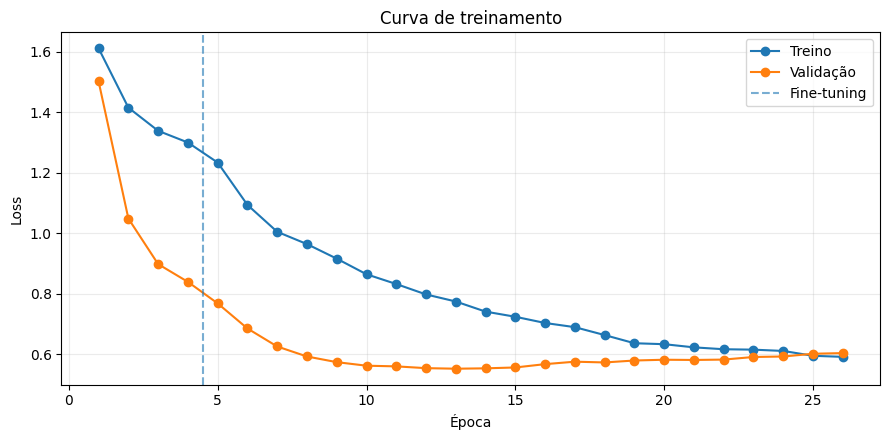

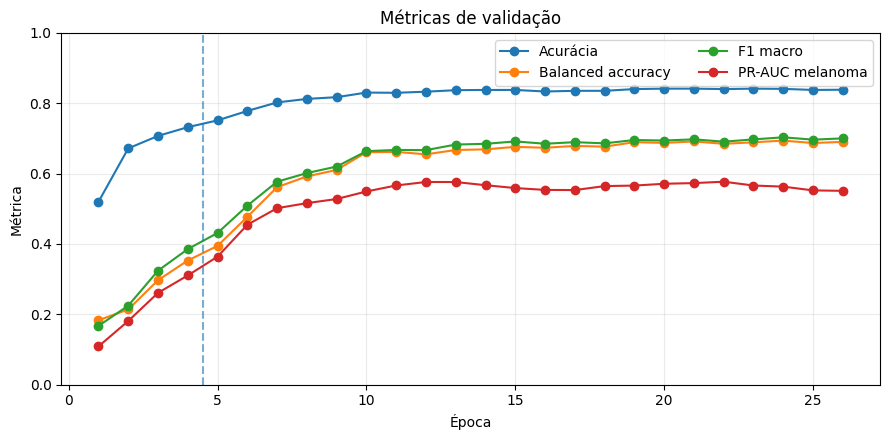

,stage,epoch,global_epoch,train_loss,val_loss,learning_rate,selection_score,val_accuracy,val_balanced_accuracy,val_f1_macro,val_roc_auc_macro_ovr,val_pr_auc_macro_ovr,val_precision_melanoma,val_recall_melanoma,val_f1_melanoma,val_pr_auc_melanoma,val_recall_high_risk
21,finetune,18,22,0.617099,0.582872,0.000028,0.703482,0.840174,0.684603,0.690704,0.959993,0.789243,0.738462,0.289157,0.415584,0.576907,0.576759
22,finetune,19,23,0.615700,0.591451,0.000028,0.704554,0.841418,0.688926,0.697199,0.958557,0.787282,0.750000,0.289157,0.417391,0.566106,0.578132
23,finetune,20,24,0.611455,0.593094,0.000010,0.706690,0.840796,0.693786,0.703102,0.957803,0.786529,0.731343,0.295181,0.420601,0.562899,0.586429
24,finetune,21,25,0.595409,0.602158,0.000010,0.700033,0.837687,0.686813,0.696454,0.956185,0.782281,0.705882,0.289157,0.410256,0.552268,0.570469
25,finetune,22,26,0.591922,0.604327,0.000010,0.701838,0.838308,0.690192,0.700052,0.956329,0.781158,0.685714,0.289157,0.406780,0.550951,0.576759


In [ ]:
def plot_training_history(history, output_dir=None):
    history = history.sort_values("global_epoch").reset_index(drop=True)
    boundary = history.loc[history["stage"].eq("head"), "global_epoch"].max()

    fig, axis = plt.subplots(figsize=(9, 4.5))
    axis.plot(history["global_epoch"], history["train_loss"], marker="o", label="Treino")
    axis.plot(history["global_epoch"], history["val_loss"], marker="o", label="Validação")
    axis.axvline(boundary + 0.5, linestyle="--", alpha=0.6, label="Fine-tuning")
    axis.set(title="Curva de treinamento", xlabel="Época", ylabel="Loss")
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    if output_dir is not None:
        fig.savefig(Path(output_dir) / "training_loss.png", dpi=160, bbox_inches="tight")
    plt.show()

    fig, axis = plt.subplots(figsize=(9, 4.5))
    axis.plot(history["global_epoch"], history["val_accuracy"], marker="o", label="Acurácia")
    axis.plot(history["global_epoch"], history["val_balanced_accuracy"], marker="o", label="Balanced accuracy")
    axis.plot(history["global_epoch"], history["val_f1_macro"], marker="o", label="F1 macro")
    axis.plot(history["global_epoch"], history["val_pr_auc_melanoma"], marker="o", label="PR-AUC melanoma")
    axis.axvline(boundary + 0.5, linestyle="--", alpha=0.6)
    axis.set(title="Métricas de validação", xlabel="Época", ylabel="Métrica", ylim=(0, 1))
    axis.grid(alpha=0.25)
    axis.legend(ncol=2)
    fig.tight_layout()
    if output_dir is not None:
        fig.savefig(Path(output_dir) / "validation_metrics.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_training_history(history_df, RUN_DIR)
display(history_df.tail())


## 10. Calibração das probabilidades

Um calibrador multiclasse é ajustado exclusivamente com a validação. A calibração não altera a ordem das classes, ela torna os valores de confiança mais coerentes com a frequência observada de acertos.

In [ ]:
def fit_logit_calibrator(validation_logits, validation_labels):
    calibrator = LogisticRegression(
        C=1.0,
        max_iter=2000,
        solver="lbfgs",
    )
    calibrator.fit(validation_logits, validation_labels)
    return calibrator


def apply_logit_calibrator(logits, calibration):
    logits = np.asarray(logits, dtype=np.float64)
    scores = logits @ calibration["coef"].T + calibration["intercept"]
    scores -= scores.max(axis=1, keepdims=True)
    probabilities = np.exp(scores)
    return probabilities / probabilities.sum(axis=1, keepdims=True)


validation_result = predict_loader(model, val_loader, use_tta=TRAINING.final_tta)
logit_calibrator = fit_logit_calibrator(
    validation_result["logits"], validation_result["labels"]
)
CALIBRATION = {
    "method": "multinomial_logit",
    "coef": logit_calibrator.coef_.astype(np.float32),
    "intercept": logit_calibrator.intercept_.astype(np.float32),
}

val_probs_raw = torch.softmax(torch.tensor(validation_result["logits"]), dim=1).numpy()
val_probs_calibrated = apply_logit_calibrator(validation_result["logits"], CALIBRATION)

validation_calibration_report = pd.DataFrame([
    {"versão": "antes", **calibration_metrics(validation_result["labels"], val_probs_raw)},
    {"versão": "calibrada", **calibration_metrics(validation_result["labels"], val_probs_calibrated)},
])
display(validation_calibration_report)


,versão,NLL,ECE,Brier
0,antes,0.567354,0.064634,0.236954
1,calibrada,0.394417,0.044369,0.197993


## 11. Alertas de alto risco

Os alertas são independentes da classe principal. Os limiares são escolhidos na validação para priorizar sensibilidade em `akiec`, `bcc` e `mel`, sem reinterpretar o alerta como diagnóstico.

In [ ]:
def choose_operating_threshold(y_true_binary, probabilities, target_recall):
    precision, recall, thresholds = precision_recall_curve(
        y_true_binary, probabilities
    )
    candidates = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })
    feasible = candidates[candidates["recall"] >= target_recall].copy()
    if feasible.empty:
        return float(candidates.loc[candidates["recall"].idxmax(), "threshold"])
    feasible["f1"] = (
        2 * feasible["precision"] * feasible["recall"]
        / np.maximum(feasible["precision"] + feasible["recall"], 1e-12)
    )
    best = feasible.sort_values(
        ["precision", "f1", "threshold"], ascending=[False, False, False]
    ).iloc[0]
    return float(best["threshold"])


def compute_alert_report(labels, probabilities, alert_thresholds):
    rows = []
    alerts = np.zeros_like(probabilities, dtype=bool)
    for code, threshold in alert_thresholds.items():
        idx = CODE_TO_IDX[code]
        y_true = (labels == idx).astype(int)
        y_pred = (probabilities[:, idx] >= threshold).astype(int)
        alerts[:, idx] = y_pred.astype(bool)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "codigo": code,
            "classe": CLASS_NAMES_PT[code],
            "threshold": threshold,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "specificity": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
            "pr_auc": safe_binary_ap(y_true, probabilities[:, idx]),
            "support": int(y_true.sum()),
            "alerts": int(y_pred.sum()),
        })
    return pd.DataFrame(rows), alerts


ALERT_THRESHOLDS = {
    code: choose_operating_threshold(
        (validation_result["labels"] == CODE_TO_IDX[code]).astype(int),
        val_probs_calibrated[:, CODE_TO_IDX[code]],
        EVALUATION.target_recall[code],
    )
    for code in EVALUATION.high_risk_codes
}

validation_alert_report, validation_alerts = compute_alert_report(
    validation_result["labels"], val_probs_calibrated, ALERT_THRESHOLDS
)
validation_metrics, validation_per_class = compute_metrics(
    validation_result["labels"],
    val_probs_calibrated,
    val_probs_calibrated.argmax(axis=1),
)

display(validation_alert_report)


,codigo,classe,threshold,precision,recall,f1,specificity,pr_auc,support,alerts
0,akiec,Ceratose actínica,0.124365,0.505747,0.830189,0.628571,0.972347,0.702290,53,87
1,bcc,Carcinoma basocelular,0.167372,0.821053,0.896552,0.857143,0.988823,0.931480,87,95
2,mel,Melanoma,0.062787,0.341067,0.885542,0.492462,0.803051,0.633421,166,431


## 12. Avaliação no conjunto de teste

O teste é executado após o congelamento do modelo da calibração e dos limiares. São apresentados resultados por imagem, por lesão, por classe, matrizes de confusão e curvas de confiabilidade.

In [ ]:
test_result = predict_loader(model, test_loader, use_tta=TRAINING.final_tta)
test_probs_raw = torch.softmax(
    torch.tensor(test_result["logits"]), dim=1
).numpy()
test_probs = apply_logit_calibrator(test_result["logits"], CALIBRATION)
test_predictions = test_probs.argmax(axis=1)

test_metrics, test_per_class = compute_metrics(
    test_result["labels"], test_probs, test_predictions
)
test_alert_report, test_alerts = compute_alert_report(
    test_result["labels"], test_probs, ALERT_THRESHOLDS
)

test_calibration_report = pd.DataFrame([
    {"versão": "antes", **calibration_metrics(test_result["labels"], test_probs_raw)},
    {"versão": "calibrada", **calibration_metrics(test_result["labels"], test_probs)},
])

display(pd.DataFrame([test_metrics]))
display(test_per_class)
display(test_alert_report)
display(test_calibration_report)

print(
    classification_report(
        test_result["labels"],
        test_predictions,
        labels=ALL_LABELS,
        target_names=[CLASS_NAMES_PT[code] for code in CLASS_CODES],
        digits=4,
        zero_division=0,
    )
)

prediction_data = {
    "image_id": test_result["image_ids"],
    "lesion_id": test_result["lesion_ids"],
    "real_idx": test_result["labels"],
    "real_code": [IDX_TO_CODE[int(idx)] for idx in test_result["labels"]],
    "pred_idx": test_predictions,
    "pred_code": [IDX_TO_CODE[int(idx)] for idx in test_predictions],
    "confidence": test_probs.max(axis=1),
}
for idx, code in enumerate(CLASS_CODES):
    prediction_data[f"prob_{code}"] = test_probs[:, idx]
for code in EVALUATION.high_risk_codes:
    prediction_data[f"alert_{code}"] = test_alerts[:, CODE_TO_IDX[code]]

test_predictions_df = pd.DataFrame(prediction_data)


,accuracy,balanced_accuracy,f1_macro,roc_auc_macro_ovr,pr_auc_macro_ovr,precision_melanoma,recall_melanoma,f1_melanoma,pr_auc_melanoma,recall_high_risk
0,0.857286,0.70382,0.724306,0.952462,0.759941,0.678788,0.511416,0.583333,0.651873,0.589099


,codigo,classe,precision,recall,f1,specificity,roc_auc,pr_auc,support
0,akiec,Ceratose actínica,0.709091,0.573529,0.634146,0.991706,0.946277,0.649019,68
1,bcc,Carcinoma basocelular,0.743590,0.682353,0.711656,0.989540,0.928766,0.724302,85
2,bkl,Ceratose benigna,0.779221,0.796460,0.787746,0.971203,0.960724,0.846992,226
3,df,Dermatofibroma,0.619048,0.464286,0.530612,0.995937,0.965156,0.539275,28
4,mel,Melanoma,0.678788,0.511416,0.583333,0.970191,0.902153,0.651873,219
5,nv,Nevo melanocítico,0.906960,0.955838,0.930758,0.801815,0.965135,0.979879,1336
6,vasc,Lesão vascular,0.846154,0.942857,0.891892,0.996942,0.999024,0.928248,35


,codigo,classe,threshold,precision,recall,f1,specificity,pr_auc,support,alerts
0,akiec,Ceratose actínica,0.124365,0.573034,0.750000,0.649682,0.980301,0.649019,68,89
1,bcc,Carcinoma basocelular,0.167372,0.700000,0.741176,0.720000,0.985879,0.724302,85,90
2,mel,Melanoma,0.062787,0.317881,0.876712,0.466586,0.768279,0.651873,219,604


,versão,NLL,ECE,Brier
0,antes,0.546935,0.062801,0.229830
1,calibrada,0.449434,0.029059,0.212993


                       precision    recall  f1-score   support

    Ceratose actínica     0.7091    0.5735    0.6341        68
Carcinoma basocelular     0.7436    0.6824    0.7117        85
     Ceratose benigna     0.7792    0.7965    0.7877       226
       Dermatofibroma     0.6190    0.4643    0.5306        28
             Melanoma     0.6788    0.5114    0.5833       219
    Nevo melanocítico     0.9070    0.9558    0.9308      1336
       Lesão vascular     0.8462    0.9429    0.8919        35

             accuracy                         0.8573      1997
            macro avg     0.7547    0.7038    0.7243      1997
         weighted avg     0.8487    0.8573    0.8508      1997



In [ ]:
probability_columns = [f"prob_{code}" for code in CLASS_CODES]

lesion_predictions_df = (
    test_predictions_df
    .groupby("lesion_id", as_index=False)
    .agg({
        "real_idx": "first",
        "real_code": "first",
        **{column: "mean" for column in probability_columns},
    })
)

lesion_probs = lesion_predictions_df[probability_columns].to_numpy()
lesion_predictions = lesion_probs.argmax(axis=1)
lesion_predictions_df["pred_idx"] = lesion_predictions
lesion_predictions_df["pred_code"] = [
    IDX_TO_CODE[int(idx)] for idx in lesion_predictions
]
lesion_predictions_df["confidence"] = lesion_probs.max(axis=1)

lesion_alert_report, lesion_alerts = compute_alert_report(
    lesion_predictions_df["real_idx"].to_numpy(),
    lesion_probs,
    ALERT_THRESHOLDS,
)
lesion_metrics, lesion_per_class = compute_metrics(
    lesion_predictions_df["real_idx"].to_numpy(),
    lesion_probs,
    lesion_predictions,
)

for code in EVALUATION.high_risk_codes:
    lesion_predictions_df[f"alert_{code}"] = lesion_alerts[:, CODE_TO_IDX[code]]

print("Métricas agregadas por lesion_id:")
display(pd.DataFrame([lesion_metrics]))
display(lesion_alert_report)


Métricas agregadas por lesion_id:


,accuracy,balanced_accuracy,f1_macro,roc_auc_macro_ovr,pr_auc_macro_ovr,precision_melanoma,recall_melanoma,f1_melanoma,pr_auc_melanoma,recall_high_risk
0,0.896921,0.705941,0.734279,0.967973,0.787565,0.77907,0.54918,0.644231,0.699333,0.593666


,codigo,classe,threshold,precision,recall,f1,specificity,pr_auc,support,alerts
0,akiec,Ceratose actínica,0.124365,0.533333,0.727273,0.615385,0.980690,0.571822,44,60
1,bcc,Carcinoma basocelular,0.167372,0.692308,0.818182,0.750000,0.986101,0.779636,55,65
2,mel,Melanoma,0.062787,0.304469,0.893443,0.454167,0.818513,0.699333,122,358


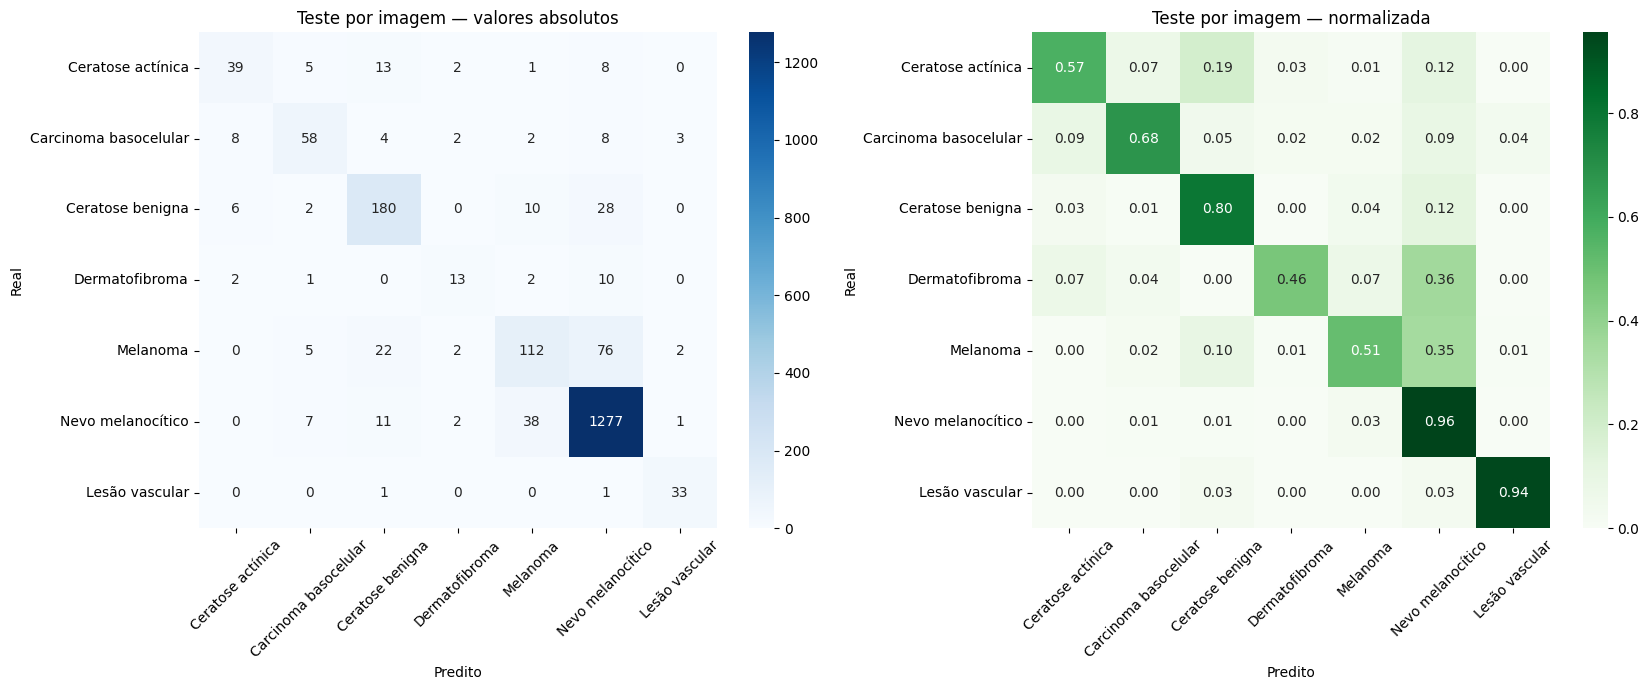

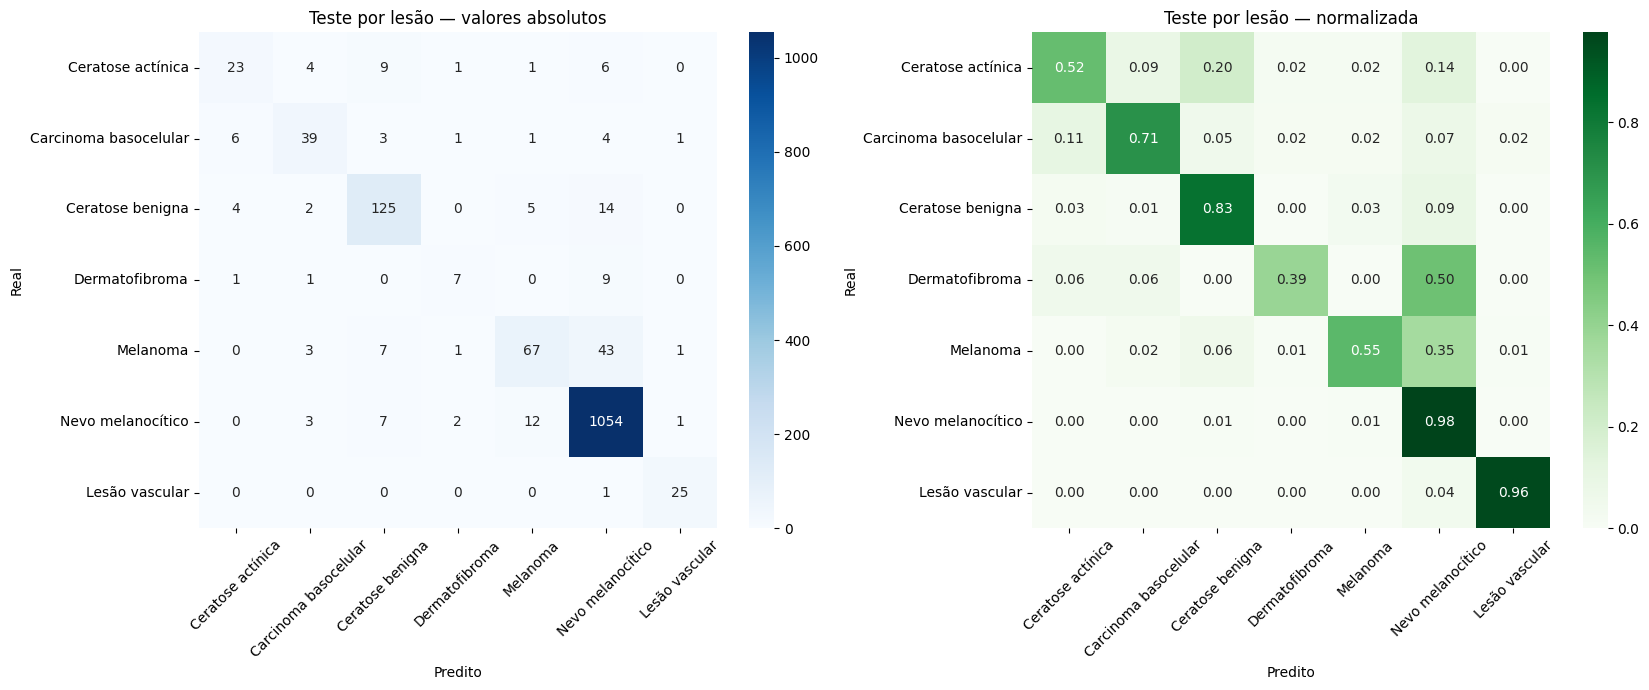

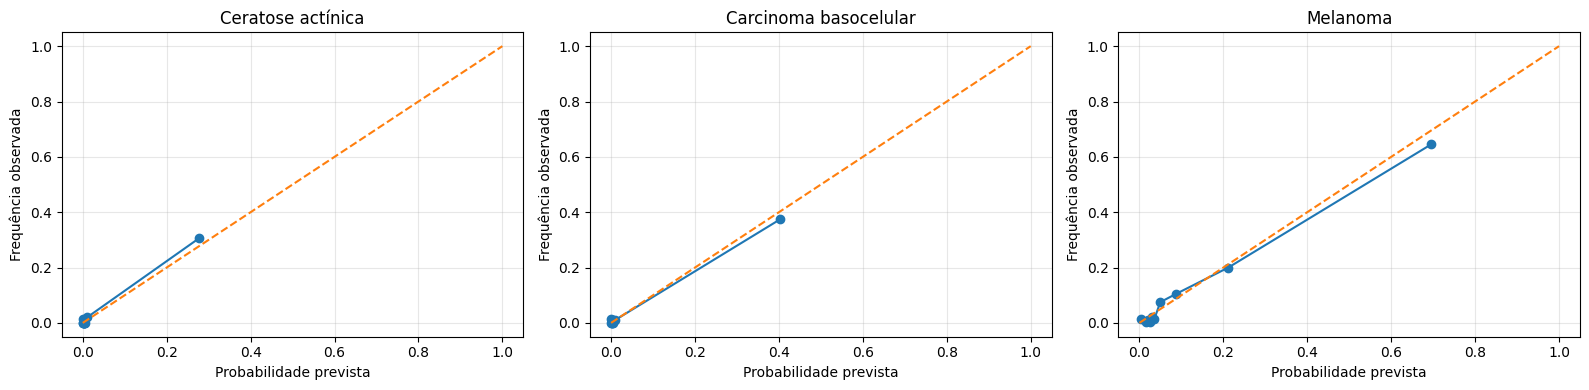

In [ ]:
def plot_confusion_matrices(y_true, y_pred, title_prefix):
    cm = confusion_matrix(y_true, y_pred, labels=ALL_LABELS)
    cm_normalized = confusion_matrix(
        y_true, y_pred, labels=ALL_LABELS, normalize="true"
    )
    class_names = [CLASS_NAMES_PT[code] for code in CLASS_CODES]
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[0].set_title(f"{title_prefix} — valores absolutos")
    axes[1].set_title(f"{title_prefix} — normalizada")
    for axis in axes:
        axis.set_xlabel("Predito")
        axis.set_ylabel("Real")
        axis.tick_params(axis="x", rotation=45)
        axis.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    return fig, cm, cm_normalized


confusion_figure, test_cm, test_cm_normalized = plot_confusion_matrices(
    test_result["labels"], test_predictions, "Teste por imagem"
)
confusion_path = RUN_DIR / "confusion_matrices_image.png"
confusion_figure.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.show()

lesion_confusion_figure, lesion_cm, lesion_cm_normalized = plot_confusion_matrices(
    lesion_predictions_df["real_idx"], lesion_predictions, "Teste por lesão"
)
lesion_confusion_path = RUN_DIR / "confusion_matrices_lesion.png"
lesion_confusion_figure.savefig(lesion_confusion_path, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, len(EVALUATION.high_risk_codes), figsize=(16, 4))
for axis, code in zip(axes, EVALUATION.high_risk_codes):
    idx = CODE_TO_IDX[code]
    y_binary = (test_result["labels"] == idx).astype(int)
    fraction_positive, mean_predicted = calibration_curve(
        y_binary, test_probs[:, idx], n_bins=10, strategy="quantile"
    )
    axis.plot(mean_predicted, fraction_positive, marker="o")
    axis.plot([0, 1], [0, 1], linestyle="--")
    axis.set_title(CLASS_NAMES_PT[code])
    axis.set_xlabel("Probabilidade prevista")
    axis.set_ylabel("Frequência observada")
    axis.grid(alpha=0.3)
plt.tight_layout()
reliability_path = RUN_DIR / "reliability_high_risk.png"
plt.savefig(reliability_path, dpi=160, bbox_inches="tight")
plt.show()


## 13. Intervalos de confiança

O bootstrap é realizado por `lesion_id`, preservando a dependência entre imagens da mesma lesão. Os intervalos ajudam a representar a incerteza das métricas, especialmente nas classes com menor suporte.

In [ ]:
def _binary_precision_recall(y_true, y_pred):
    precision, recall, _, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    return float(precision), float(recall)


def _bootstrap_values(y_true, y_pred, probabilities, alert_matrix):
    metrics, per_class = compute_metrics(y_true, probabilities, y_pred)
    mel_true = (np.asarray(y_true) == MELANOMA_IDX).astype(int)
    mel_alert = alert_matrix[:, MELANOMA_IDX].astype(int)
    alert_precision_mel, alert_recall_mel = _binary_precision_recall(
        mel_true, mel_alert
    )

    high_risk_alert_recalls = []
    for idx in HIGH_RISK_IDXS:
        true_binary = (np.asarray(y_true) == idx).astype(int)
        pred_binary = alert_matrix[:, idx].astype(int)
        _, recall_value = _binary_precision_recall(true_binary, pred_binary)
        high_risk_alert_recalls.append(recall_value)

    values = {
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "f1_macro": metrics["f1_macro"],
        "classification_recall_melanoma": metrics["recall_melanoma"],
        "alert_precision_melanoma": alert_precision_mel,
        "alert_recall_melanoma": alert_recall_mel,
        "alert_recall_high_risk": float(np.mean(high_risk_alert_recalls)),
    }

    for idx, code in enumerate(CLASS_CODES):
        values[f"precision_{code}"] = float(per_class.loc[idx, "precision"])
        values[f"recall_{code}"] = float(per_class.loc[idx, "recall"])
        values[f"pr_auc_{code}"] = float(per_class.loc[idx, "pr_auc"])
    return values


def group_bootstrap_confidence_intervals(
    y_true,
    y_pred,
    probabilities,
    alert_matrix,
    groups,
    iterations,
    seed,
    confidence=0.95,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    probabilities = np.asarray(probabilities)
    alert_matrix = np.asarray(alert_matrix)
    groups = np.asarray(groups)
    unique_groups = np.unique(groups)
    group_to_indices = {
        group: np.flatnonzero(groups == group) for group in unique_groups
    }
    rng = np.random.default_rng(seed)
    samples = []

    for _ in tqdm(range(iterations), leave=False):
        sampled_groups = rng.choice(
            unique_groups, size=len(unique_groups), replace=True
        )
        sampled_indices = np.concatenate([
            group_to_indices[group] for group in sampled_groups
        ])
        samples.append(_bootstrap_values(
            y_true[sampled_indices],
            y_pred[sampled_indices],
            probabilities[sampled_indices],
            alert_matrix[sampled_indices],
        ))

    samples_df = pd.DataFrame(samples)
    point = _bootstrap_values(y_true, y_pred, probabilities, alert_matrix)
    alpha = 1.0 - confidence
    rows = []
    for metric, point_value in point.items():
        rows.append({
            "metrica": metric,
            "estimativa": float(point_value),
            "IC_inferior": float(samples_df[metric].quantile(alpha / 2)),
            "IC_superior": float(samples_df[metric].quantile(1 - alpha / 2)),
        })
    return pd.DataFrame(rows), samples_df


bootstrap_ci, bootstrap_samples = group_bootstrap_confidence_intervals(
    test_result["labels"],
    test_predictions,
    test_probs,
    test_alerts,
    test_result["lesion_ids"],
    EVALUATION.bootstrap_iterations,
    TRAINING.seed,
)
display(bootstrap_ci)


  0%|          | 0/500 [00:00<?, ?it/s]

,metrica,estimativa,IC_inferior,IC_superior
0,accuracy,0.857286,0.837964,0.875628
1,balanced_accuracy,0.703820,0.657536,0.752089
2,f1_macro,0.724306,0.670799,0.766845
3,classification_recall_melanoma,0.511416,0.426221,0.601326
4,alert_precision_melanoma,0.317881,0.271949,0.362369
5,alert_recall_melanoma,0.876712,0.832986,0.920533
6,alert_recall_high_risk,0.789296,0.729980,0.848093
7,precision_akiec,0.709091,0.541667,0.839162
8,recall_akiec,0.573529,0.413552,0.718566
9,pr_auc_akiec,0.649019,0.472363,0.782969


## 14. Exportação do checkpoint

O checkpoint reúne pesos, arquitetura, tamanho de entrada, normalização, classes, calibração, limiares e metadados do experimento. Dessa forma, a inferência não depende das variáveis criadas durante o treinamento.

In [ ]:
PRELIMINARY_METRICS = {
    "image_level": test_metrics,
    "lesion_level": lesion_metrics,
    "test_calibration": {
        row["versão"]: {"NLL": row["NLL"], "ECE": row["ECE"], "Brier": row["Brier"]}
        for row in test_calibration_report.to_dict(orient="records")
    },
}

checkpoint = {
    "schema_version": "3.0",
    "model_version": RUN_NAME,
    "state_dict": {key: value.detach().cpu() for key, value in model.state_dict().items()},
    "architecture": TRAINING.architecture,
    "num_classes": NUM_CLASSES,
    "image_size": TRAINING.image_size,
    "class_codes": CLASS_CODES,
    "class_names_pt": CLASS_NAMES_PT,
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "calibration": {
        "method": CALIBRATION["method"],
        "coef": CALIBRATION["coef"].tolist(),
        "intercept": CALIBRATION["intercept"].tolist(),
    },
    "decision_rule": "argmax_with_independent_alerts",
    "alert_thresholds": {code: float(value) for code, value in ALERT_THRESHOLDS.items()},
    "metrics": PRELIMINARY_METRICS,
    "training_config": asdict(TRAINING),
    "dataset_fingerprint": DATASET_FINGERPRINT,
    "split_fingerprint": SPLIT_FINGERPRINT,
    "created_at": datetime.now(timezone.utc).isoformat(),
}

candidate_checkpoint_path = RUN_DIR / "modelo_dermascan.pth"
torch.save(checkpoint, candidate_checkpoint_path)
print("Checkpoint:", candidate_checkpoint_path)


Checkpoint: artifacts/dermascan/experiments/efficientnet_b4_20260803_042339/modelo_dermascan.pth


## 15. Robustez da entrada e paridade

Esta etapa implementa a leitura segura de imagens, valida dimensões e conteúdo visual, reconstrói o modelo diretamente do checkpoint e compara a inferência carregada com o modelo ainda em memória.

In [ ]:
MINIMUM_IMAGE_DIMENSION = 128
MAXIMUM_IMAGE_PIXELS = 40_000_000
MINIMUM_IMAGE_STD = 2.0


def validate_inference_image(image: Image.Image) -> Image.Image:
    image = ImageOps.exif_transpose(image)
    width, height = image.size

    if min(width, height) < MINIMUM_IMAGE_DIMENSION:
        raise ValueError(
            f"Imagem com resolução insuficiente: {width}x{height}. "
            f"O menor lado deve ter pelo menos {MINIMUM_IMAGE_DIMENSION}px."
        )
    if width * height > MAXIMUM_IMAGE_PIXELS:
        raise ValueError("Imagem excede o limite permitido de pixels.")

    image = image.convert("RGB")
    image_array = np.asarray(image, dtype=np.float32)
    if float(image_array.std()) < MINIMUM_IMAGE_STD:
        raise ValueError("Imagem sem variação visual suficiente para inferência.")

    return image


def load_image_source(source) -> Image.Image:
    if isinstance(source, Image.Image):
        return validate_inference_image(source.copy())

    if isinstance(source, (str, os.PathLike, Path)):
        image_path = Path(source)
        if not image_path.is_file():
            raise FileNotFoundError(f"Imagem não encontrada: {image_path}")
        try:
            with Image.open(image_path) as image:
                image.load()
                return validate_inference_image(image.copy())
        except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as error:
            raise ValueError("Arquivo de imagem inválido ou não suportado.") from error

    if hasattr(source, "read"):
        source = source.read()

    if isinstance(source, (bytes, bytearray, memoryview)):
        try:
            with Image.open(io.BytesIO(bytes(source))) as image:
                image.load()
                return validate_inference_image(image.copy())
        except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as error:
            raise ValueError("Bytes de imagem inválidos ou não suportados.") from error

    raise TypeError(
        "A entrada deve ser um caminho, PIL.Image, bytes ou objeto de arquivo."
    )


def decode_base64_image(value: str) -> bytes:
    if not isinstance(value, str) or not value.strip():
        raise ValueError("A imagem Base64 deve ser uma string não vazia.")

    payload = value.split(",", 1)[1] if value.lstrip().startswith("data:image/") else value
    try:
        return base64.b64decode(payload, validate=True)
    except (ValueError, TypeError) as error:
        raise ValueError("Conteúdo Base64 inválido.") from error


def build_checkpoint_transform(loaded_checkpoint):
    normalization = loaded_checkpoint["normalization"]
    return transforms.Compose([
        transforms.Resize(
            (loaded_checkpoint["image_size"], loaded_checkpoint["image_size"]),
            antialias=True,
        ),
        transforms.ToTensor(),
        transforms.Normalize(normalization["mean"], normalization["std"]),
    ])


def probabilities_from_logits(logits: torch.Tensor, loaded_checkpoint) -> np.ndarray:
    calibration = loaded_checkpoint.get("calibration")
    if not calibration:
        return torch.softmax(logits.float(), dim=1).cpu().numpy()

    if calibration.get("method") != "multinomial_logit":
        raise ValueError(f"Calibração não suportada: {calibration.get('method')}")

    logits_array = logits.float().cpu().numpy().astype(np.float64)
    coefficients = np.asarray(calibration["coef"], dtype=np.float64)
    intercept = np.asarray(calibration["intercept"], dtype=np.float64)
    scores = logits_array @ coefficients.T + intercept
    scores -= scores.max(axis=1, keepdims=True)
    probabilities = np.exp(scores)
    return probabilities / probabilities.sum(axis=1, keepdims=True)


def forward_with_tta(model, tensor, *, use_tta, device):
    views = [tensor]
    if use_tta:
        views.extend([
            torch.flip(tensor, dims=[3]),
            torch.flip(tensor, dims=[2]),
            torch.flip(tensor, dims=[2, 3]),
        ])

    with torch.inference_mode(), torch.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=device.type == "cuda",
    ):
        logits = torch.stack([model(view) for view in views]).mean(dim=0)

    return logits


In [ ]:
class DermaScanPredictor:
    REQUIRED_CHECKPOINT_FIELDS = {
        "state_dict",
        "architecture",
        "num_classes",
        "image_size",
        "class_codes",
        "class_names_pt",
        "normalization",
    }

    def __init__(self, checkpoint_file, *, device=None, use_tta=None):
        self.checkpoint_path = Path(checkpoint_file).expanduser().resolve()
        if not self.checkpoint_path.is_file():
            raise FileNotFoundError(f"Checkpoint não encontrado: {self.checkpoint_path}")

        self.device = torch.device(
            device or ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.checkpoint = torch.load(
            self.checkpoint_path,
            map_location="cpu",
            weights_only=True,
        )

        missing_fields = self.REQUIRED_CHECKPOINT_FIELDS.difference(self.checkpoint)
        if missing_fields:
            raise ValueError(
                "Checkpoint incompleto. Campos ausentes: "
                + ", ".join(sorted(missing_fields))
            )

        self.model = timm.create_model(
            self.checkpoint["architecture"],
            pretrained=False,
            num_classes=int(self.checkpoint["num_classes"]),
            drop_rate=0.0,
            drop_path_rate=0.0,
        )
        self.model.load_state_dict(self.checkpoint["state_dict"], strict=True)
        self.model.to(self.device).eval()

        self.transform = build_checkpoint_transform(self.checkpoint)
        training_config = self.checkpoint.get("training_config", {})
        self.use_tta = (
            bool(training_config.get("final_tta", False))
            if use_tta is None
            else bool(use_tta)
        )

    def predict_probabilities(self, source) -> np.ndarray:
        image = load_image_source(source)
        tensor = self.transform(image).unsqueeze(0).to(self.device)
        logits = forward_with_tta(
            self.model,
            tensor,
            use_tta=self.use_tta,
            device=self.device,
        )
        probabilities = probabilities_from_logits(logits, self.checkpoint)[0]

        if not np.isfinite(probabilities).all():
            raise RuntimeError("A inferência produziu probabilidades inválidas.")
        if not np.isclose(probabilities.sum(), 1.0, atol=1e-6):
            raise RuntimeError("As probabilidades não somam 1.")

        return probabilities.astype(np.float64)

    def predict(self, source) -> dict:
        probabilities = self.predict_probabilities(source)
        class_codes = list(self.checkpoint["class_codes"])
        class_names = dict(self.checkpoint["class_names_pt"])
        thresholds = {
            code: float(value)
            for code, value in self.checkpoint.get("alert_thresholds", {}).items()
        }

        prediction_index = int(probabilities.argmax())
        prediction_code = class_codes[prediction_index]

        alerts = {
            code: bool(probabilities[class_codes.index(code)] >= threshold)
            for code, threshold in thresholds.items()
        }
        alert_details = {
            code: {
                "ativo": alerts[code],
                "probabilidade": float(probabilities[class_codes.index(code)]),
                "limiar": threshold,
            }
            for code, threshold in thresholds.items()
        }

        ranking = sorted(
            [
                {
                    "codigo": code,
                    "classe": class_names[code],
                    "probabilidade": float(probabilities[index]),
                    "probabilidade_percentual": round(float(probabilities[index]) * 100, 2),
                    "alerta": bool(alerts.get(code, False)),
                }
                for index, code in enumerate(class_codes)
            ],
            key=lambda item: item["probabilidade"],
            reverse=True,
        )

        return {
            "classe_principal": class_names[prediction_code],
            "codigo": prediction_code,
            "confianca": float(probabilities[prediction_index]),
            "confianca_percentual": round(float(probabilities[prediction_index]) * 100, 2),
            "alerta_atencao": any(alerts.values()),
            "alertas": alerts,
            "alertas_detalhados": alert_details,
            "probabilidades": {
                code: float(probabilities[index])
                for index, code in enumerate(class_codes)
            },
            "ranking": ranking,
            "modelo": self.checkpoint.get("model_version"),
            "schema_version": self.checkpoint.get("schema_version"),
            "tta": self.use_tta,
        }

    def predict_base64(self, image_base64: str) -> dict:
        return self.predict(decode_base64_image(image_base64))


In [ ]:
candidate_predictor = DermaScanPredictor(
    candidate_checkpoint_path,
    device=DEVICE,
    use_tta=TRAINING.final_tta,
)

parity_sample_path = Path(test_df.iloc[0]["path"])
parity_image = load_image_source(parity_sample_path)
parity_tensor = candidate_predictor.transform(parity_image).unsqueeze(0).to(DEVICE)

memory_logits = forward_with_tta(
    model,
    parity_tensor,
    use_tta=TRAINING.final_tta,
    device=DEVICE,
)
memory_probabilities = probabilities_from_logits(memory_logits, checkpoint)[0]
checkpoint_probabilities = candidate_predictor.predict_probabilities(parity_sample_path)

np.testing.assert_allclose(
    memory_probabilities,
    checkpoint_probabilities,
    rtol=1e-5,
    atol=1e-6,
)

with parity_sample_path.open("rb") as file:
    bytes_result = candidate_predictor.predict(file.read())
path_result = candidate_predictor.predict(parity_sample_path)

assert path_result["codigo"] == bytes_result["codigo"]
np.testing.assert_allclose(
    list(path_result["probabilidades"].values()),
    list(bytes_result["probabilidades"].values()),
    rtol=1e-5,
    atol=1e-6,
)

print("Paridade confirmada entre o modelo em memória, o checkpoint e a entrada em bytes.")


Paridade confirmada entre o modelo em memória, o checkpoint e a entrada em bytes.


## 16. Persistência dos artefatos

Além do modelo final, o experimento salva métricas, histórico, configurações, previsões, gráficos e um arquivo compactado da execução.

In [ ]:
def json_default(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Tipo não serializável: {type(value)!r}")


final_metrics = {
    "image_level": test_metrics,
    "lesion_level": lesion_metrics,
    "alerts_image": test_alert_report.to_dict(orient="records"),
    "alerts_lesion": lesion_alert_report.to_dict(orient="records"),
    "calibration": test_calibration_report.to_dict(orient="records"),
    "best_validation": best_record["metrics"],
}
checkpoint["metrics"] = final_metrics
torch.save(checkpoint, candidate_checkpoint_path)

MODEL_EXPORT_PATH = MODEL_ROOT / "modelo_dermascan.pth"
METRICS_EXPORT_PATH = MODEL_ROOT / "metricas_dermascan.json"
shutil.copy2(candidate_checkpoint_path, MODEL_EXPORT_PATH)

with open(METRICS_EXPORT_PATH, "w", encoding="utf-8") as file:
    json.dump(final_metrics, file, ensure_ascii=False, indent=2, default=json_default)
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as file:
    json.dump(asdict(TRAINING), file, ensure_ascii=False, indent=2, default=json_default)
with open(RUN_DIR / "environment.json", "w", encoding="utf-8") as file:
    json.dump(ENVIRONMENT, file, ensure_ascii=False, indent=2, default=json_default)

history_df.to_csv(RUN_DIR / "training_history.csv", index=False)
test_per_class.to_csv(RUN_DIR / "metrics_per_class_image.csv", index=False)
lesion_per_class.to_csv(RUN_DIR / "metrics_per_class_lesion.csv", index=False)
test_alert_report.to_csv(RUN_DIR / "alert_metrics_image.csv", index=False)
test_calibration_report.to_csv(RUN_DIR / "calibration.csv", index=False)
bootstrap_ci.to_csv(RUN_DIR / "confidence_intervals.csv", index=False)
test_predictions_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

archive_path = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)

print("Modelo salvo em:", MODEL_EXPORT_PATH.resolve())
print("Métricas salvas em:", METRICS_EXPORT_PATH.resolve())
print("Experimento compactado em:", Path(archive_path).resolve())


Modelo salvo em: /content/artifacts/dermascan/models/modelo_dermascan.pth
Métricas salvas em: /content/artifacts/dermascan/models/metricas_dermascan.json
Experimento compactado em: /content/artifacts/dermascan/experiments/efficientnet_b4_20260803_042339.zip


## 17. Inferência e integração


In [ ]:
checkpoint_path = (
    Path(MODEL_EXPORT_PATH)
    if "MODEL_EXPORT_PATH" in globals()
    else Path("artifacts/dermascan/models/modelo_dermascan.pth")
)

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Modelo não encontrado em: {checkpoint_path.resolve()}\n"
        "Execute primeiro a etapa de exportação do modelo."
    )

predictor = DermaScanPredictor(
    checkpoint_file=checkpoint_path,
)

upload_widget = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False,
    description="Selecionar imagem",
)

analyze_button = widgets.Button(
    description="Analisar imagem",
    button_style="primary",
    icon="search",
)

output_widget = widgets.Output()


def get_uploaded_image_bytes(upload) -> bytes:
    uploaded_files = upload.value

    if not uploaded_files:
        raise ValueError("Selecione uma imagem antes de analisar.")

    # Compatibilidade com ipywidgets 7 e 8
    if isinstance(uploaded_files, dict):
        uploaded_file = next(iter(uploaded_files.values()))
    else:
        uploaded_file = uploaded_files[0]

    if isinstance(uploaded_file, dict):
        content = uploaded_file["content"]
    else:
        content = uploaded_file.content

    image_bytes = bytes(content)

    if not image_bytes:
        raise ValueError("O arquivo enviado está vazio.")

    return image_bytes


def analyze_uploaded_image(_):
    with output_widget:
        clear_output(wait=True)

        try:
            image_bytes = get_uploaded_image_bytes(upload_widget)

            with Image.open(io.BytesIO(image_bytes)) as image:
                image.load()
                preview_image = image.convert("RGB")

            display(preview_image)

            result = predictor.predict(image_bytes)

            print(f"Classe principal: {result['classe_principal']}")
            print(f"Confiança: {result['confianca_percentual']:.2f}%")
            print(
                "Alerta de atenção:",
                "Sim" if result["alerta_atencao"] else "Não",
            )

            ranking = pd.DataFrame(result["ranking"])[
                [
                    "classe",
                    "probabilidade_percentual",
                    "alerta",
                ]
            ].copy()

            ranking.columns = [
                "Classe",
                "Probabilidade (%)",
                "Alerta",
            ]

            display(ranking)

        except Exception as error:
            print(f"Não foi possível analisar a imagem: {error}")


analyze_button.on_click(analyze_uploaded_image)

display(
    widgets.VBox(
        [
            widgets.HTML(
                """
                <h3>Teste de inferência</h3>
                <p>Selecione uma imagem JPG, JPEG ou PNG da lesão.</p>
                """
            ),
            upload_widget,
            analyze_button,
            output_widget,
        ]
    )
)

## Conclusão

Portanto, esse notebook desenvolveu um pipeline completo para classificação de lesões dermatoscópicas com EfficientNet-B4 incluindo treinamento, calibração, definição de alertas e exportação do modelo.

No conjunto de teste, o modelo alcançou 85,73% de acurácia e 72,43% de F1 macro. A calibração tornou as probabilidades mais confiáveis enquanto o sistema de alerta priorizou a identificação de casos potencialmente relevantes.

Os resultados são promissores mas o modelo ainda necessita de validação externa e não deve ser utilizado como diagnóstico médico. O arquivo `modelo_dermascan.pth` reúne os artefatos necessários para integração com o serviço de inferência do DermaScan.

In [ ]:
import shutil
from google.colab import files

arquivo_zip = shutil.make_archive(
    "/content/artifacts_dermascan",
    "zip",
    "/content/artifacts",
)

files.download(arquivo_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>